In [1]:
from pathlib import Path
import sys
import os

notebook_dir = Path().resolve()
project_root = notebook_dir.parent.parent
os.chdir(str(project_root))
sys.path.insert(0, str(project_root))

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import pickle
from evaluation.benchmark_universeg.benchmark_2d import EvalPipeline2D

I0000 00:00:1777621086.184671      65 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


# UniverSeg vs Prompt U-Net Comparison

This notebook runs the automated evaluation pipeline to compare the performance of **UniverSeg** and **Prompt-UNet** on 2D datasets.

In [2]:
pipeline = EvalPipeline2D()

offset = 'offset_5'
p_unet_version = '316'

model_name = 'prompt_unet'
model = 'p_unet_316'
output_name = f"results_{model}_{offset}.pkl"

# model_name = 'universeg'
# output_name = f"results_{model_name}_{offset}.pkl"

data_path = f"data/test_data/2d/{offset}"

results = pipeline.run_full_evaluation(
    data_path=data_path, 
    model_name=model_name,
    p_unet_version=p_unet_version, 
    batch_size = 32,
    output_file=f"evaluation/benchmark_universeg/{output_name}"
)

Starting evaluation on: data/test_data/2d/offset_5
Discovered 500 dataset(s).
Loading 'prompt_unet' model...


I0000 00:00:1777621105.262403      65 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 46640 MB memory:  -> device: 0, name: NVIDIA RTX A6000, pci bus id: 0000:81:00.0, compute capability: 8.6
Evaluating prompt_unet: 100%|██████████| 500/500 [19:33<00:00,  2.35s/it]


Final Results for prompt_unet:
  Prompt U-Net (V316) Mean Dice : 0.7598  (Avg Time: 1.14s/dataset)
Results saved to evaluation/benchmark_universeg/results_p_unet_316_offset_5.pkl


# Plot results

In [3]:
prompt_pkl_name = "evaluation/benchmark_universeg/results_p_unet_316_offset"
univer_pkl_name = "evaluation/benchmark_universeg/results_universeg_offset"


=== Offset 5 ===
Prompt U-Net


,dice,time,task
count,500.000,500.000,500.000
mean,0.760,1.142,15.302
std,0.200,0.182,14.546
min,0.117,0.608,1.000
25%,0.667,1.065,3.000
50%,0.832,1.120,10.000
75%,0.902,1.189,25.000
max,0.979,3.974,55.000


Universeg


,dice,time,task
count,500.000,500.000,500.000
mean,0.600,1.800,15.302
std,0.268,0.385,14.546
min,0.019,0.959,1.000
25%,0.405,1.556,3.000
50%,0.699,1.766,10.000
75%,0.806,1.961,25.000
max,0.939,4.608,55.000



=== Offset 12 ===
Prompt U-Net


,dice,time,task
count,500.000,500.000,500.000
mean,0.681,1.013,15.776
std,0.215,0.256,14.476
min,0.077,0.190,1.000
25%,0.535,0.944,4.000
50%,0.736,0.999,11.000
75%,0.853,1.075,24.250
max,0.971,5.193,56.000


Universeg


,dice,time,task
count,500.000,500.000,500.000
mean,0.594,1.803,15.776
std,0.268,0.520,14.476
min,0.011,0.457,1.000
25%,0.413,1.512,4.000
50%,0.681,1.770,11.000
75%,0.801,2.035,24.250
max,0.963,7.966,56.000


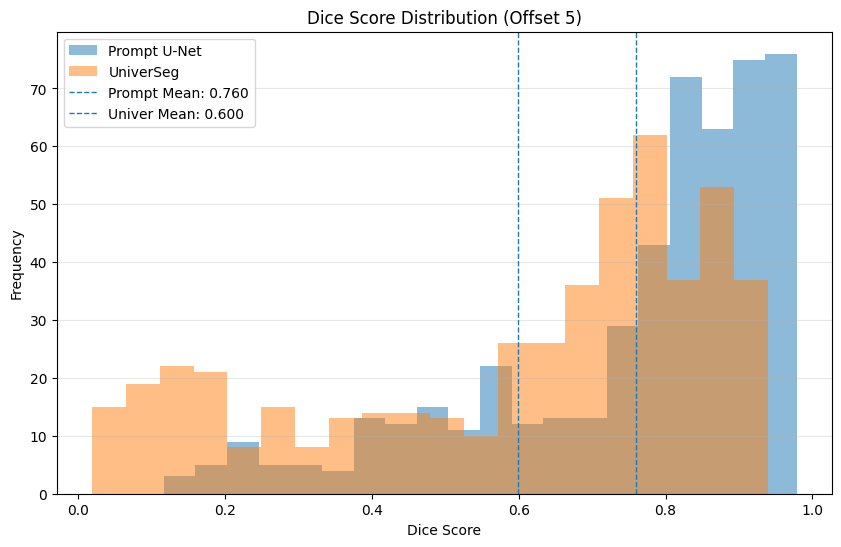

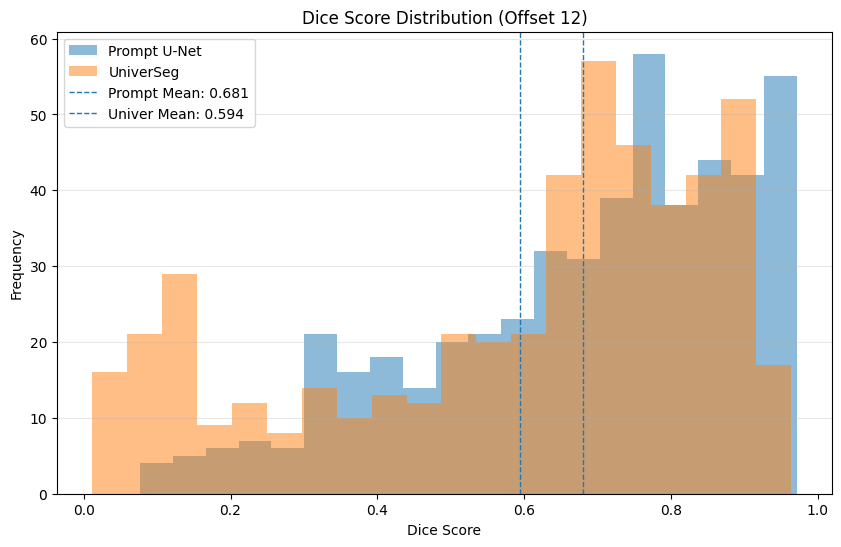

/tmp/ipykernel_65/403010865.py:65: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=labels)


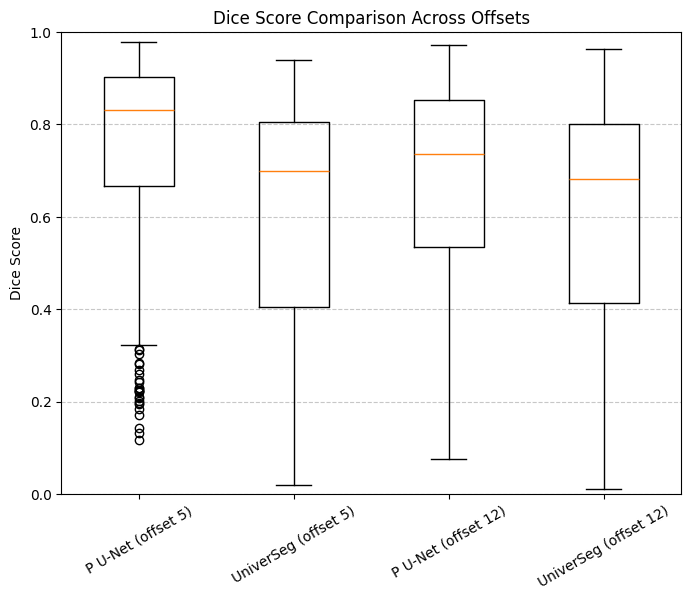

In [5]:
import pandas as pd
pd.set_option('display.float_format', '{:.3f}'.format)
import matplotlib.pyplot as plt

offsets = [5, 12]

results = {}

# Load and store results
for offset in offsets:
    prompt = pd.read_pickle(f"{prompt_pkl_name}_{offset}.pkl")
    univer = pd.read_pickle(f"{univer_pkl_name}_{offset}.pkl")

    df_prompt = pd.DataFrame(prompt)
    df_univer = pd.DataFrame(univer)

    print(f"\n=== Offset {offset} ===")
    print("Prompt U-Net")
    display(df_prompt.describe())
    print("Universeg")
    display(df_univer.describe())

    results[offset] = {
        "prompt": df_prompt["dice"],
        "univer": df_univer["dice"]
    }

# ------------------------
# 1. Histograms (per offset)
# ------------------------
for offset in offsets:
    prompt_dices = results[offset]["prompt"]
    univer_dices = results[offset]["univer"]

    plt.figure(figsize=(10, 6))
    plt.hist(prompt_dices, bins=20, alpha=0.5, label='Prompt U-Net')
    plt.hist(univer_dices, bins=20, alpha=0.5, label='UniverSeg')

    plt.axvline(prompt_dices.mean(), linestyle='dashed', linewidth=1,
                label=f'Prompt Mean: {prompt_dices.mean():.3f}')
    plt.axvline(univer_dices.mean(), linestyle='dashed', linewidth=1,
                label=f'Univer Mean: {univer_dices.mean():.3f}')

    plt.title(f"Dice Score Distribution (Offset {offset})")
    plt.xlabel("Dice Score")
    plt.ylabel("Frequency")
    plt.legend()
    plt.grid(axis='y', alpha=0.3)
    plt.show()

# ------------------------
# 2. Combined Boxplot
# ------------------------
data = []
labels = []

for offset in offsets:
    data.append(results[offset]["prompt"])
    labels.append(f"P U-Net (offset {offset})")

    data.append(results[offset]["univer"])
    labels.append(f"UniverSeg (offset {offset})")

plt.figure(figsize=(8, 6))
plt.boxplot(data, labels=labels)
plt.ylabel("Dice Score")
plt.ylim(0, 1.0)
plt.title("Dice Score Comparison Across Offsets")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=30)
plt.show()

# Per dataset scores

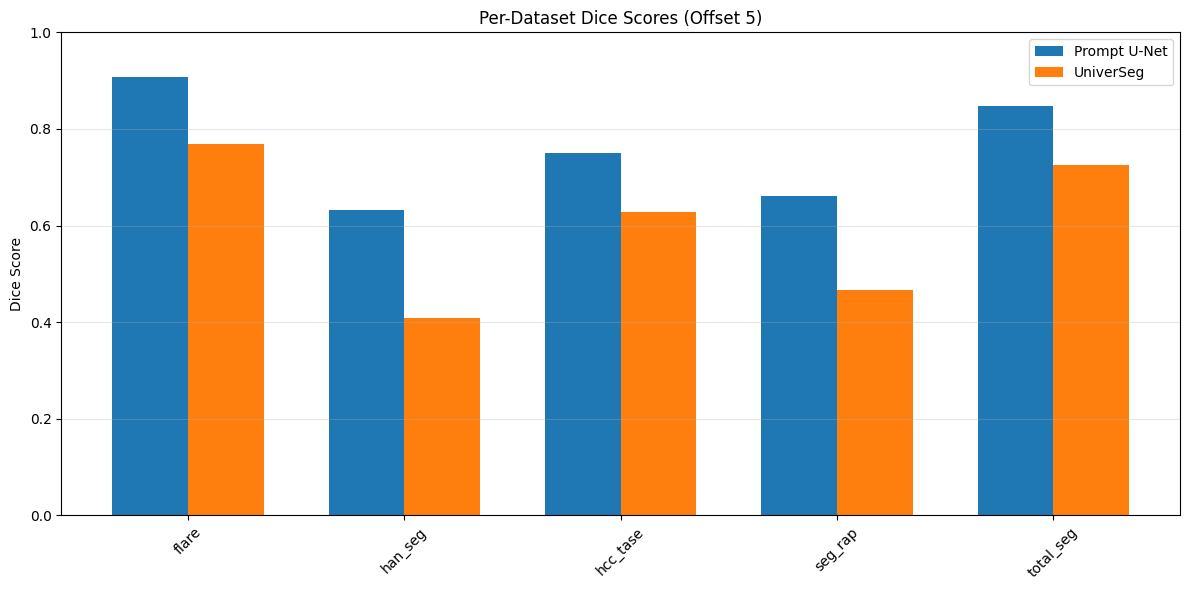

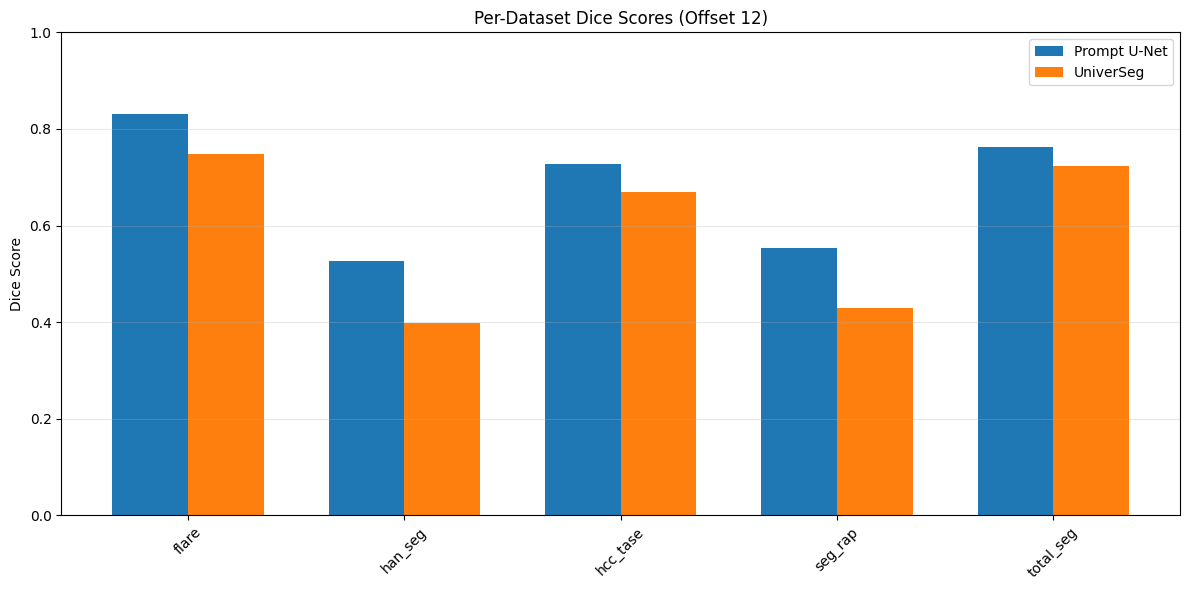

In [7]:
def clean_name(name):
    return name.split("_", 1)[1] if "_" in name else name

offsets = [5, 12]

for offset in offsets:
    prompt = pd.read_pickle(f"{prompt_pkl_name}_{offset}.pkl")
    univer = pd.read_pickle(f"{univer_pkl_name}_{offset}.pkl")
    df_prompt = pd.DataFrame(prompt)
    df_univer = pd.DataFrame(univer)

    # Clean dataset names
    df_prompt["dataset"] = df_prompt["name"].apply(clean_name)
    df_univer["dataset"] = df_univer["name"].apply(clean_name)

    # Aggregate (mean Dice per dataset)
    prompt_grouped = df_prompt.groupby("dataset")["dice"].mean().reset_index()
    univer_grouped = df_univer.groupby("dataset")["dice"].mean().reset_index()

    # Merge
    merged = prompt_grouped.rename(columns={"dice": "prompt"}).merge(
        univer_grouped.rename(columns={"dice": "univer"}),
        on="dataset"
    )

    results[offset]["merged"] = merged
    
    
    df = results[offset]["merged"].sort_values("dataset")

    x = range(len(df))
    width = 0.35

    plt.figure(figsize=(12, 6))

    plt.bar([i - width/2 for i in x], df["prompt"], width=width, label="Prompt U-Net")
    plt.bar([i + width/2 for i in x], df["univer"], width=width, label="UniverSeg")

    plt.xticks(x, df["dataset"], rotation=45)
    plt.ylabel("Dice Score")
    plt.ylim(0, 1.0)
    plt.title(f"Per-Dataset Dice Scores (Offset {offset})")

    plt.legend()
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()